In [2]:
import matplotlib.pyplot as plt
import json
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister, assemble
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2, Session, SamplerOptions
from qtcodes import XXZZQubit
import time
import numpy as np
import os
import pandas as pd
from qiskit.providers.fake_provider import GenericBackendV2

In [3]:
global api_token, service, backends
api_token = 'be5e713d2a8fa9228e96fbb61a84af3337e4730a2d7a174eaeeb8c625f964b516a29f367490a0fa50ec5de4dff1be879e018c6f87e906a15b379519049c9868a'

service = QiskitRuntimeService(
    channel="ibm_quantum",
    token=api_token,
    #instance="ibm-q-education/columbia-uni-2/computer-science"
)

backends =  service.backends()[:-1]

In [4]:
import networkx as nx
from qiskit import QuantumCircuit

# -----------------------------
# 1) Extract Connectivity from Circuit
# -----------------------------
def circuit_to_connectivity_graph(qc: QuantumCircuit, exclude_ancillas=True) -> nx.Graph:
    """
    Given a Qiskit QuantumCircuit, return a NetworkX Graph
    where nodes represent qubits and edges represent 2-qubit interactions.
    """
    G = nx.Graph()
    
    # Extract qubit mappings
    qubit_mapping = qc.layout.initial_layout.get_physical_bits()  # Maps logical qubits to physical indices
    
    # Identify ancilla qubits
    ancilla_qubits = set()
    if exclude_ancillas:
        for idx, qubit in qubit_mapping.items():
            if "ancilla" == qubit._register.name:  # Filter based on register name
                ancilla_qubits.add(idx)

    # Add edges for each 2-qubit gate (excluding ancillas if requested)
    for instr, qargs, _ in qc.data:
        if len(qargs) == 2:  # Only consider 2-qubit interactions
            q0 = qc.find_bit(qargs[0]).index
            q1 = qc.find_bit(qargs[1]).index

            if exclude_ancillas and (q0 in ancilla_qubits or q1 in ancilla_qubits):
                continue  # Skip ancilla interactions

            G.add_edge(q0, q1)

    return G

# -----------------------------
# 2) Obtain Backend Connectivity Graph
# -----------------------------
def backend_to_graph(backend) -> nx.Graph:
    """
    Given a Qiskit backend (real or simulator),
    build a NetworkX Graph of its qubit connectivity.
    """
    config = backend.configuration()
    coupling_map = config.coupling_map  # e.g. [[0,1],[1,2],...]
    # print(coupling_map)
    
    G = nx.Graph()
    G.add_nodes_from(range(config.num_qubits))
    
    for edge in coupling_map:
        G.add_edge(edge[0], edge[1])  # Undirected edge
    
    return G

# -----------------------------
# 3) Perform Subgraph Isomorphism
# -----------------------------
def find_subgraph_isomorphisms(subgraph: nx.Graph, full_graph: nx.Graph):
    """
    Find all subgraph isomorphisms mapping 'subgraph' inside 'full_graph'.
    Returns a list of dictionaries, where each dict maps subgraph nodes
    to full_graph nodes.
    """
    gm = nx.algorithms.isomorphism.GraphMatcher(full_graph, subgraph)
    return list(gm.subgraph_isomorphisms_iter())

In [8]:
# 2) Pick a backend and build its connectivity graph
backend = backends[0]
print(f'Backend = {backend.name}')
backend_graph = backend_to_graph(backend)
print(f'\tConnectivity graph: {backend_graph.number_of_edges()} edges, {backend_graph.number_of_nodes()} nodes')

qubit_d5_circ = XXZZQubit({'d': 3})
qubit_d5_circ.x()
qubit_d5_circ.stabilize()
qc = transpile(qubit_d5_circ.circ, backend, optimization_level=3) 

#Extract the circuit's connectivity
circ_graph = circuit_to_connectivity_graph(qc)
print(f'Circuit connectivity graph: {circ_graph.number_of_edges()} edges, {circ_graph.number_of_nodes()} nodes')

Backend = ibm_brisbane
	Connectivity graph: 144 edges, 127 nodes
Circuit connectivity graph: 16 edges, 17 nodes


/var/folders/k3/27w60qks2nn1dv0q05k_30z40000gn/T/ipykernel_41719/1330301203.py:25: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for instr, qargs, _ in qc.data:


/var/folders/k3/27w60qks2nn1dv0q05k_30z40000gn/T/ipykernel_41719/1330301203.py:25: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for instr, qargs, _ in qc.data:


Circuit connectivity graph: 16 edges, 17 nodes


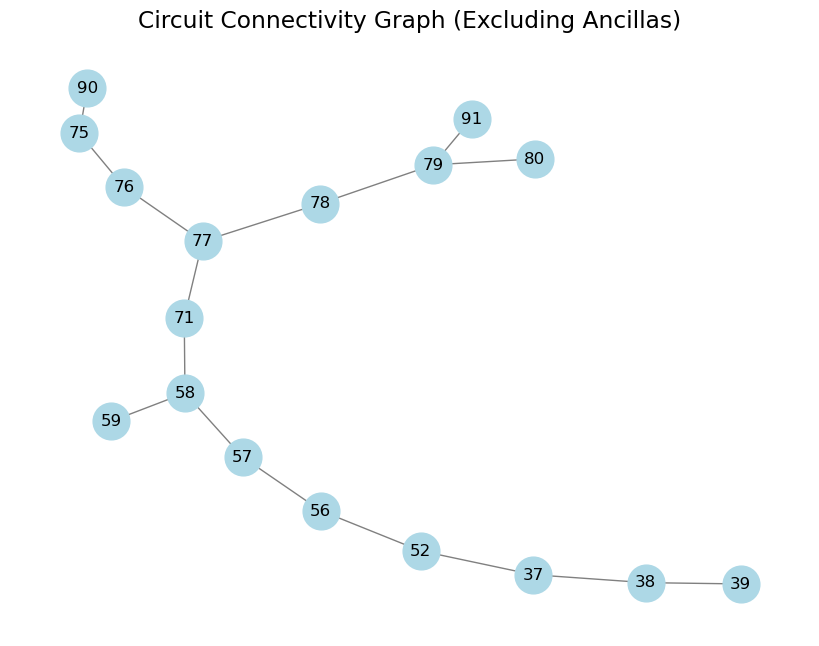

In [10]:
circuit_graph = circuit_to_connectivity_graph(qc)

print(f"Circuit connectivity graph: {circuit_graph.number_of_edges()} edges, {circuit_graph.number_of_nodes()} nodes")

# Optional: Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
nx.draw(circuit_graph, with_labels=True, node_color='lightblue', edge_color='gray', node_size=700)
plt.title("Circuit Connectivity Graph (Excluding Ancillas)")
plt.show()

In [14]:
import networkx as nx
import random

def random_subgraph_isomorphism(
    sub_graph: nx.Graph,
    full_graph: nx.Graph,
    max_attempts=100,
    verbose=True
):
    """
    Attempt a random backtracking search to find a single subgraph isomorphism.
    If found, return it. Otherwise, return None.
    
    - sub_graph: smaller graph we want to embed
    - full_graph: larger graph
    - max_attempts: safety limit to avoid infinite loops
    - verbose: if True, prints detailed logs
    """
    
    sub_nodes = list(sub_graph.nodes())
    full_nodes = list(full_graph.nodes())
    
    # Shuffle the sub_graph nodes so each attempt tries a fresh ordering
    random.shuffle(sub_nodes)
    if verbose:
        print(f"[INFO] Shuffled sub_graph nodes: {sub_nodes}")

    used_in_full = set()     # Track which full_graph nodes are already mapped
    mapping = {}             # sub_node -> full_node

    def backtrack(i):
        """Try to assign sub_nodes[i] to a valid full_node at random."""
        if i == len(sub_nodes):
            # All sub_graph nodes assigned => successful isomorphism
            return True
        
        s_node = sub_nodes[i]
        
        # Shuffle candidates each time for random mapping order
        candidates = list(full_nodes)
        random.shuffle(candidates)
        # if verbose:
        #     print(f"  [DEBUG] Attempting to map sub_node {s_node} (index {i})")
        
        for f_node in candidates:
            if f_node in used_in_full:
                # if verbose:
                #     print(f"    [SKIP] f_node {f_node} already used")
                continue
            
            # Check adjacency constraints with already placed neighbors
            can_place = True
            for neighbor in sub_graph[s_node]:
                if neighbor in mapping:  # neighbor is already mapped
                    mapped_neighbor = mapping[neighbor]
                    if not full_graph.has_edge(f_node, mapped_neighbor):
                        can_place = False
                        # if verbose:
                        #     print(f"    [FAIL] No edge {f_node}-{mapped_neighbor} in full_graph")
                        break
            
            if can_place:
                # if verbose:
                #     print(f"    [OK] Mapped sub_node {s_node} -> {f_node}")
                mapping[s_node] = f_node
                used_in_full.add(f_node)
                
                if backtrack(i + 1):
                    return True
                
                # Backtrack
                # if verbose:
                #     print(f"    [BACKTRACK] Removing sub_node {s_node} -> {f_node}")
                used_in_full.remove(f_node)
                del mapping[s_node]
        
        return False

    # Try random backtracking up to max_attempts
    for attempt in range(1, max_attempts + 1):
        if verbose:
            print(f"\n[ATTEMPT {attempt}/{max_attempts}] Starting backtracking")
        
        # Reset any partial state from previous attempts
        used_in_full.clear()
        mapping.clear()

        if backtrack(0):
            if verbose:
                print(f"[SUCCESS] Found mapping on attempt {attempt}: {mapping}")
            return mapping
    
    if verbose:
        print(f"[FAIL] No mapping found after {max_attempts} attempts.")
    return None

In [16]:
# Usage:
single_random_mapping = random_subgraph_isomorphism(circ_graph, backend_graph)
if single_random_mapping:
    print("Found a random subgraph isomorphism:", single_random_mapping)
else:
    print("No subgraph isomorphism found (or max attempts exceeded).")

[INFO] Shuffled sub_graph nodes: [52, 75, 37, 80, 38, 78, 71, 76, 79, 59, 77, 58, 90, 91, 39, 57, 56]

[ATTEMPT 1/100] Starting backtracking



KeyboardInterrupt



In [86]:
import networkx as nx
from networkx.algorithms import isomorphism

def find_random_subgraph_isomorphism(sub_graph, full_graph, max_solutions=50000, verbose=True):
    """
    Returns a random subgraph isomorphism by:
    1. Shuffling node order before searching to introduce randomness.
    2. Collecting up to `max_solutions` valid mappings.
    3. Picking one at random from the collected solutions.

    Parameters:
    - sub_graph: nx.Graph, the smaller graph to embed
    - full_graph: nx.Graph, the larger host graph
    - max_solutions: Maximum number of solutions to collect before choosing randomly
    - verbose: If True, prints status messages

    Returns:
    - A dictionary {sub_node: full_node} representing a random subgraph isomorphism,
      or None if no isomorphism exists.
    """

    # Step 1: Shuffle node order before searching (introduces randomness)
    sub_nodes = list(sub_graph.nodes())
    full_nodes = list(full_graph.nodes())
    
    random.shuffle(sub_nodes)
    random.shuffle(full_nodes)

    # Create a GraphMatcher with shuffled node order
    GM = isomorphism.GraphMatcher(full_graph, sub_graph)

    # Step 2: Collect up to `max_solutions` valid subgraph isomorphisms
    solutions = []
    for mapping in GM.subgraph_isomorphisms_iter():
        # Convert full->sub mapping to sub->full
        sub_to_full = {sub: full for full, sub in mapping.items()}
        solutions.append(sub_to_full)
        if len(solutions) >= max_solutions:
            print(f'Hit max solutions limit: {len(solutions)}')
            break  # Stop early once we reach the desired number of solutions

    if not solutions:
        if verbose:
            print("[FAIL] No subgraph isomorphism found.")
        return None

    # Step 3: Pick one random solution from the collected ones
    chosen_mapping = random.choice(solutions)

    if verbose:
        print(f"[SUCCESS] Found {len(solutions)} subgraph isomorphisms. Picking one at random:")
        for s_node, f_node in chosen_mapping.items():
            print(f"  {s_node} -> {f_node}")

    return chosen_mapping


In [88]:
# Example usage:
sub_mapping = find_random_subgraph_isomorphism(circ_graph, backend_graph)
if sub_mapping:
    print("Found a subgraph isomorphism:", sub_mapping)
else:
    print("No isomorphism found.")

[SUCCESS] Found 2516 subgraph isomorphisms. Picking one at random:
  79 -> 83
  78 -> 82
  80 -> 92
  77 -> 81
  76 -> 80
  75 -> 79
  71 -> 72
  58 -> 62
  57 -> 61
  56 -> 60
  52 -> 59
  37 -> 58
  38 -> 57
  91 -> 84
  90 -> 91
  39 -> 56
  59 -> 63
Found a subgraph isomorphism: {79: 83, 78: 82, 80: 92, 77: 81, 76: 80, 75: 79, 71: 72, 58: 62, 57: 61, 56: 60, 52: 59, 37: 58, 38: 57, 91: 84, 90: 91, 39: 56, 59: 63}


In [ ]:
# Mapping of physical qubits (backend qubits) to logical qubits (from the circuit) as determined during transpilation
# Keys (83, 82, 84, etc.) are physical qubit indices on the quantum hardware.
# Values are logical qubits from the circuit, represented as Qubit(QuantumRegister(size, 'name'), index)
init_layout = qc.layout.initial_layout.get_physical_bits()
init_layout

In [ ]:
# mapping of logical qubits from your circuit to indexed positions in the transpiled circuit. Essentially, it tells you:
# Keys: Logical qubits from different registers (e.g., tq_data, tq_mz, tq_mx, ancilla).
# Values: The sequential index assigned to each qubit in the transpiled circuit.
qc.layout.input_qubit_mapping

In [78]:
circ_graph.number_of_nodes()

18

In [80]:
qubit_d5_circ.circ.num_qubits

18

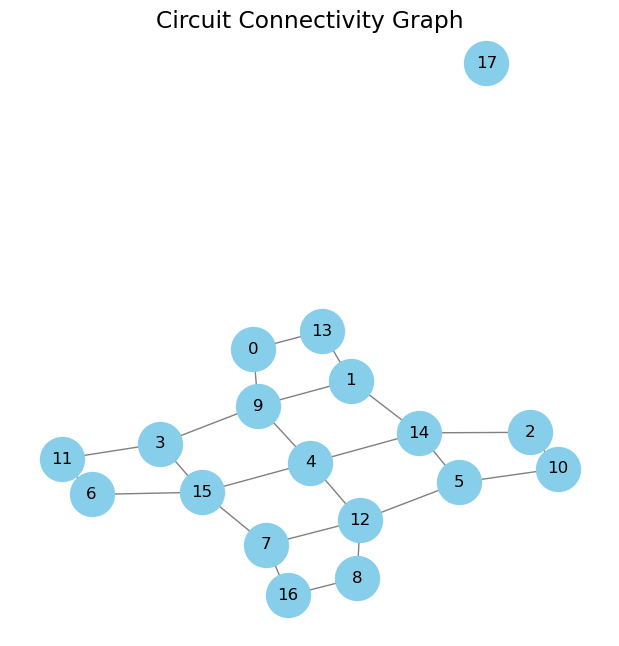

In [94]:
import matplotlib.pyplot as plt

def visualize_graph(graph, title="Graph Visualization"):
    """Visualizes a NetworkX graph using Matplotlib."""
    plt.figure(figsize=(6, 6))
    pos = nx.spring_layout(graph)  # Layout algorithm for better visualization
    nx.draw(graph, pos, with_labels=True, node_color="skyblue", edge_color="gray", node_size=1000, font_size=12)
    plt.title(title)
    plt.show()

# Example usage:
visualize_graph(circ_graph, title="Circuit Connectivity Graph")


In [ ]:
visualize_graph(qc, title="QC Connectivity Graph")

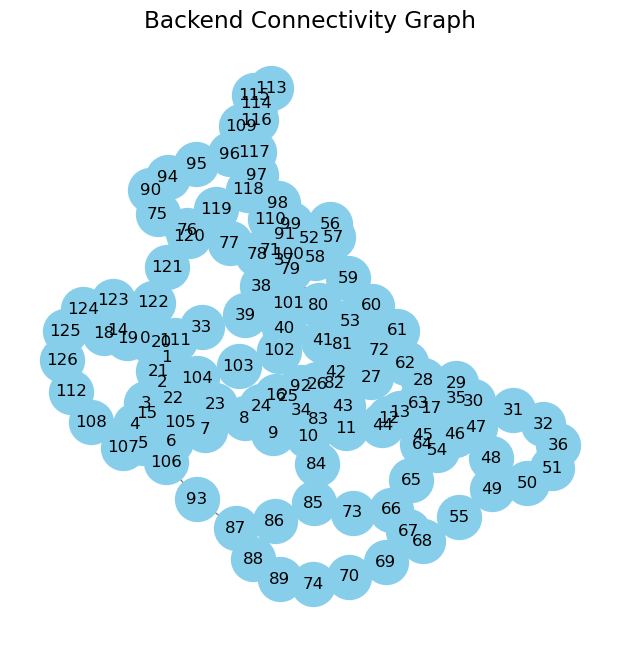

In [84]:
visualize_graph(backend_graph, title="Backend Connectivity Graph")

In [86]:
import networkx as nx

def find_subgraph_monomorphisms(subgraph: nx.Graph, full_graph: nx.Graph):
    # Create a GraphMatcher that ignores node/edge attributes
    gm = nx.algorithms.isomorphism.GraphMatcher(
        full_graph,
        subgraph,
        node_match=lambda data1, data2: True,  # ignore node attrs
        edge_match=lambda data1, data2: True   # ignore edge attrs
    )
    # Return all monomorphisms (non-induced subgraph matches)
    return list(gm.subgraph_monomorphisms_iter())

# Example usage
iso_mappings = find_subgraph_monomorphisms(circ_graph, backend_graph)
print(f"Number of monomorphisms found: {len(iso_mappings)}")


Number of monomorphisms found: 0


In [88]:
from networkx.algorithms.isomorphism import ISMAGS

def find_noninduced_isomorphisms(subgraph: nx.Graph, full_graph: nx.Graph):
    matcher = ISMAGS(
        full_graph,
        subgraph,
        node_match=lambda data1, data2: True,
        edge_match=lambda data1, data2: True,
        induced=False  # allow extra edges in full_graph
    )
    return list(matcher.find_isomorphisms())

# Example usage
iso_mappings = find_noninduced_isomorphisms(circ_graph, backend_graph)
print(f"Number of non-induced isomorphisms: {len(iso_mappings)}")


TypeError: ISMAGS.__init__() got an unexpected keyword argument 'induced'

In [96]:
print(f"Circuit Graph Nodes: {circ_graph.nodes()}")
print(f"Circuit Graph Edges: {circ_graph.edges()}")

print(f"Backend Graph Nodes: {backend_graph.nodes()}")
print(f"Backend Graph Edges: {backend_graph.edges()}")


Circuit Graph Nodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
Circuit Graph Edges: [(0, 13), (0, 9), (1, 13), (1, 14), (1, 9), (2, 14), (2, 10), (3, 15), (3, 9), (3, 11), (4, 14), (4, 15), (4, 9), (4, 12), (5, 14), (5, 10), (5, 12), (6, 15), (6, 11), (7, 15), (7, 16), (7, 12), (8, 16), (8, 12)]
Backend Graph Nodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]
Backend Graph Edges: [(0, 1), (0, 14), (1, 2), (2, 3), (3, 4), (4, 5), (4, 15), (5, 6), (6, 7), (7, 8), (8, 9), (8, 16), (9, 10), (10, 